Synthetic data set: https://www.kaggle.com/datasets/nudratabbas/global-ads-performance-google-meta-tiktok

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# Phase 1: Creating Database

In [2]:
import sqlite3

In [ ]:
global_ads_df = pd.read_csv('data/global_ads_performance_dataset.csv')

print(global_ads_df.columns.tolist())

#Impressions: number of times the ad was shown
#CTR: click-through rate (clicks / impressions)
#CPC: cost per click
#CPA: cost per acquisition
#ROAS: return on ad spend (revenue / spend)

['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']


In [4]:
conn = sqlite3. connect('global_ads.db')

global_ads_df.to_sql('global_ads', conn, if_exists = 'replace', index = False)

print('Database saved!')

Database saved!


# Phase 2: Exploratory Data Analysis & SQL Querying

In [ ]:
query1 = """
    SELECT DISTINCT 
        platform, 
        country, 
        SUM(impressions) AS total_impressions, 
        SUM(clicks) AS total_clicks, 
        SUM(conversions) AS total_conversions
    FROM global_ads
    GROUP BY country, platform
    ORDER BY country, platform
"""

query1_df = pd.read_sql_query(query1, conn)
query1_df['click_rate'] = round((query1_df['total_clicks'] / query1_df['total_impressions']), 4)
query1_df['click_to_conversion_rate'] = round((query1_df['total_conversions'] / query1_df['total_clicks']), 4)

query1_df

,platform,country,total_impressions,total_clicks,total_conversions,click_rate,click_to_conversion_rate
0,Google Ads,Australia,11074095,447654,20914,0.0404,0.0467
1,Meta Ads,Australia,6421987,162572,7677,0.0253,0.0472
2,TikTok Ads,Australia,6305418,350699,17278,0.0556,0.0493
3,Google Ads,Canada,11308339,430478,17995,0.0381,0.0418
4,Meta Ads,Canada,8851252,202200,8943,0.0228,0.0442
5,TikTok Ads,Canada,7241692,402126,19305,0.0555,0.0480
6,Google Ads,Germany,9898258,401337,18063,0.0405,0.0450
7,Meta Ads,Germany,9847695,239088,11254,0.0243,0.0471
8,TikTok Ads,Germany,6372853,354146,15451,0.0556,0.0436
9,Google Ads,India,9119665,330113,14995,0.0362,0.0454


In [6]:
query2 = """
    SELECT
         CASE strftime('%m', date) 
            WHEN '01' THEN 'January'
            WHEN '02' THEN 'February'
            WHEN '03' THEN 'March'
            WHEN '04' THEN 'April'
            WHEN '05' THEN 'May'
            WHEN '06' THEN 'June'
            WHEN '07' THEN 'July'
            WHEN '08' THEN 'August'
            WHEN '09' THEN 'September'
            WHEN '10' THEN 'October'
            WHEN '11' THEN 'November'
            WHEN '12' THEN 'December'
            ELSE NULL
         END AS month, 
         platform, SUM(impressions) AS month_impressions, 
         SUM(clicks) AS month_clicks, 
         SUM(conversions) AS month_conversions
    FROM global_ads
    GROUP BY month, platform
    ORDER BY CASE month
                WHEN 'January' THEN 1
                WHEN 'February' THEN 2
                WHEN 'March' THEN 3
                WHEN 'April' THEN 4
                WHEN 'May' THEN 5
                WHEN 'June' THEN 6
                WHEN 'July' THEN 7
                WHEN 'August' THEN 8
                WHEN 'September' THEN 9
                WHEN 'October' THEN 10
                WHEN 'November' THEN 11
                WHEN 'December' THEN 12
                ELSE NULL
            END, date
"""

query2_df = pd.read_sql_query(query2, conn)
query2_df

,month,platform,month_impressions,month_clicks,month_conversions
0,January,Meta Ads,7463528,186457,8641
1,January,Google Ads,5374750,195369,8970
2,January,TikTok Ads,4137760,230249,10434
3,February,Meta Ads,4625254,123078,5624
4,February,TikTok Ads,4416464,255369,11793
5,February,Google Ads,6348968,259429,11146
6,March,Meta Ads,5761195,120524,5402
7,March,Google Ads,6379805,244800,10733
8,March,TikTok Ads,3230417,173775,8493
9,April,TikTok Ads,4932459,272248,12491


# Phase 3: Data Visualization

In [7]:
# Global dark theme settings
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "monospace"
})

print("Style loaded!")


Style loaded!


## Performance & Efficiency
- Which platform delivers the best ROAS and lowest CPA overall?
- Which campaign type is most cost-efficient by CPC and conversion rate?
- Is there a relationship between impression volume and CTR -- do larger campaigns get better or worse click rates?

### Charts 1 & 2: Platform Average ROAS and CPA

In [18]:
best_roas_query = """
    SELECT platform, campaign_type, AVG(roas) AS avg_roas, AVG(cpa) AS avg_cpa
    FROM global_ads
    GROUP BY platform, campaign_type
    ORDER BY avg_roas DESC, avg_cpa ASC
"""

best_roas = pd.read_sql_query(best_roas_query, conn)
best_roas

,platform,campaign_type,avg_roas,avg_cpa
0,TikTok Ads,Search,10.519280,27.314800
1,TikTok Ads,Display,10.036931,26.714950
2,TikTok Ads,Video,9.572286,29.630000
3,TikTok Ads,Shopping,8.055798,32.897563
4,Meta Ads,Display,7.270138,35.860483
5,Meta Ads,Search,6.902312,41.451500
6,Meta Ads,Shopping,6.767500,38.074562
7,Meta Ads,Video,6.761030,40.649212
8,Google Ads,Search,4.790885,57.729583
9,Google Ads,Video,4.141828,65.778495


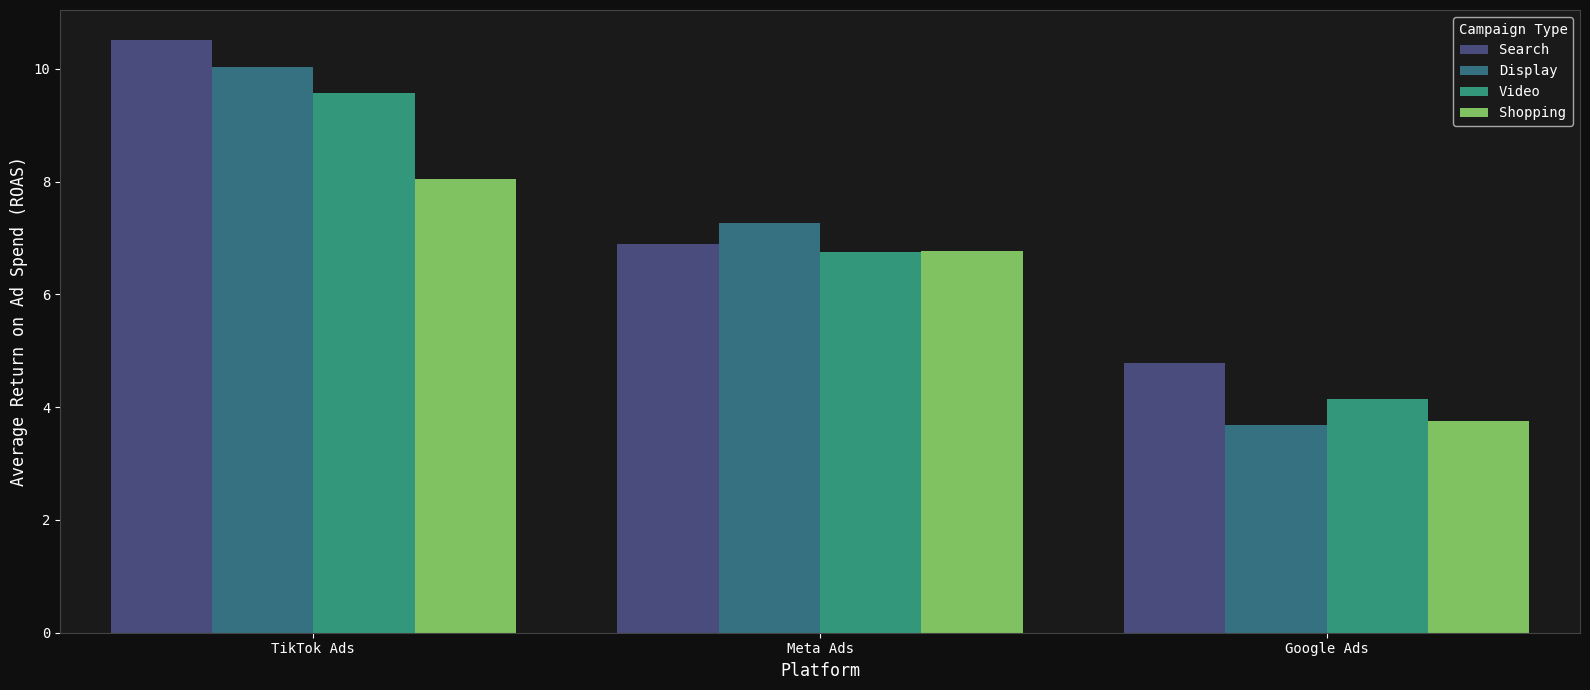

In [24]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data = best_roas, x='platform', y='avg_roas', hue='campaign_type', palette = 'viridis')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Average Return on Ad Spend (ROAS)', fontsize=12)

legend = plt.gca().get_legend()
legend.set_title('Campaign Type')

plt.tight_layout()
plt.show()

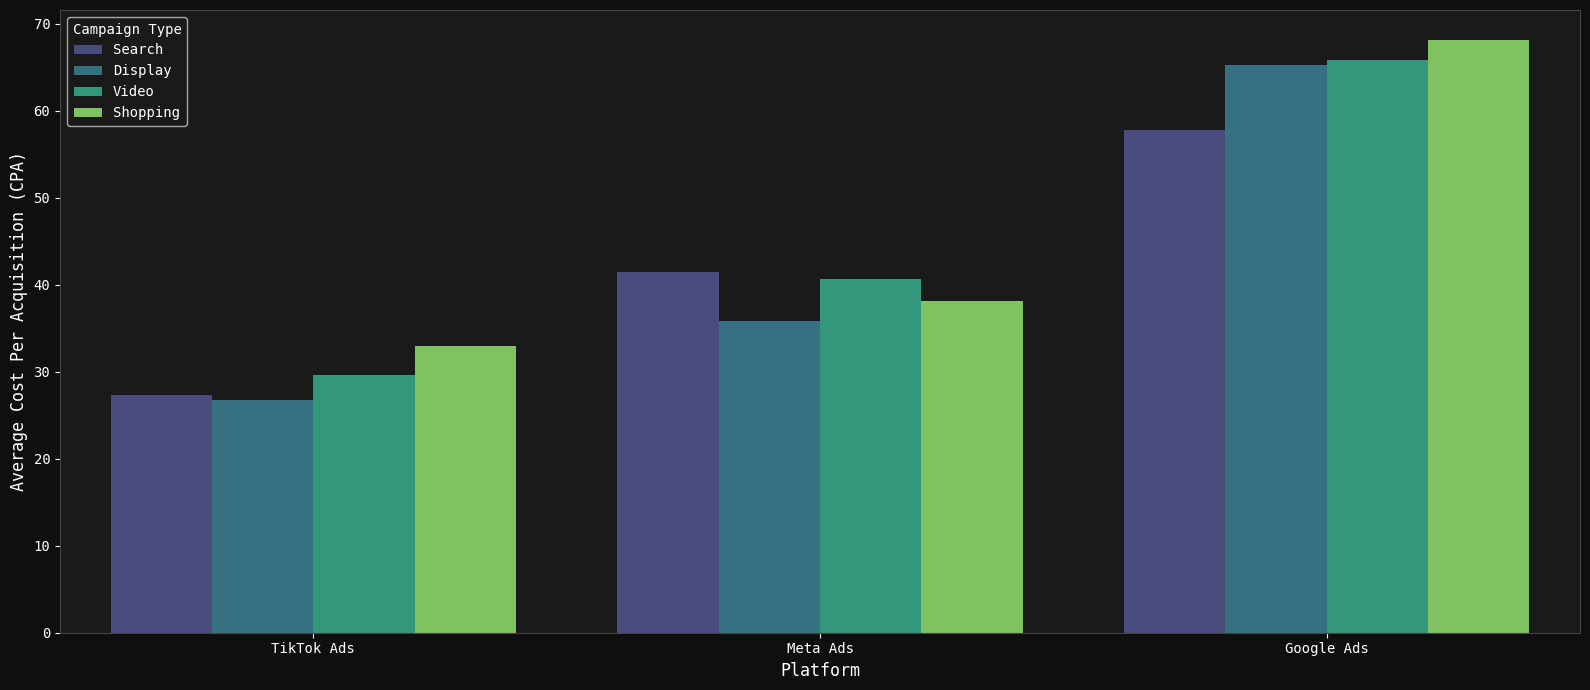

In [41]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data = best_roas, x='platform', y='avg_cpa', hue='campaign_type', palette = 'viridis')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Average Cost Per Acquisition (CPA)', fontsize=12)

legend = plt.gca().get_legend()
legend.set_title('Campaign Type')

plt.tight_layout()
plt.show()

### Charts 3 & 4: Cost Efficiency by CPC & Conversion Rate

In [37]:
cpc_efficiency_query = """
    SELECT 
        campaign_type, 
        industry,
        AVG(CPC) AS avg_cpc, 
        SUM(ad_spend) AS total_ad_spend,
        SUM(conversions) AS total_conversions,
        SUM(ad_spend) / SUM(conversions) AS cost_per_conversion
    FROM global_ads
    GROUP BY campaign_type, industry
    ORDER BY campaign_type, industry
"""

cpc_efficiency = pd.read_sql_query(cpc_efficiency_query, conn)
cpc_efficiency

,campaign_type,industry,avg_cpc,total_ad_spend,total_conversions,cost_per_conversion
0,Display,E-commerce,1.593973,381665.23,11656,32.744100
1,Display,EdTech,1.724045,578034.15,14224,40.637946
2,Display,Fintech,1.636883,487095.49,13647,35.692496
3,Display,Healthcare,1.753256,652777.71,18438,35.403933
4,Display,SaaS,1.387158,545162.54,18904,28.838475
5,Search,E-commerce,1.484563,546792.06,17884,30.574372
6,Search,EdTech,1.452549,556920.83,20382,27.324150
7,Search,Fintech,1.574066,632533.19,17836,35.463848
8,Search,Healthcare,1.591200,615555.21,18058,34.087674
9,Search,SaaS,1.563580,516205.56,16481,31.321252


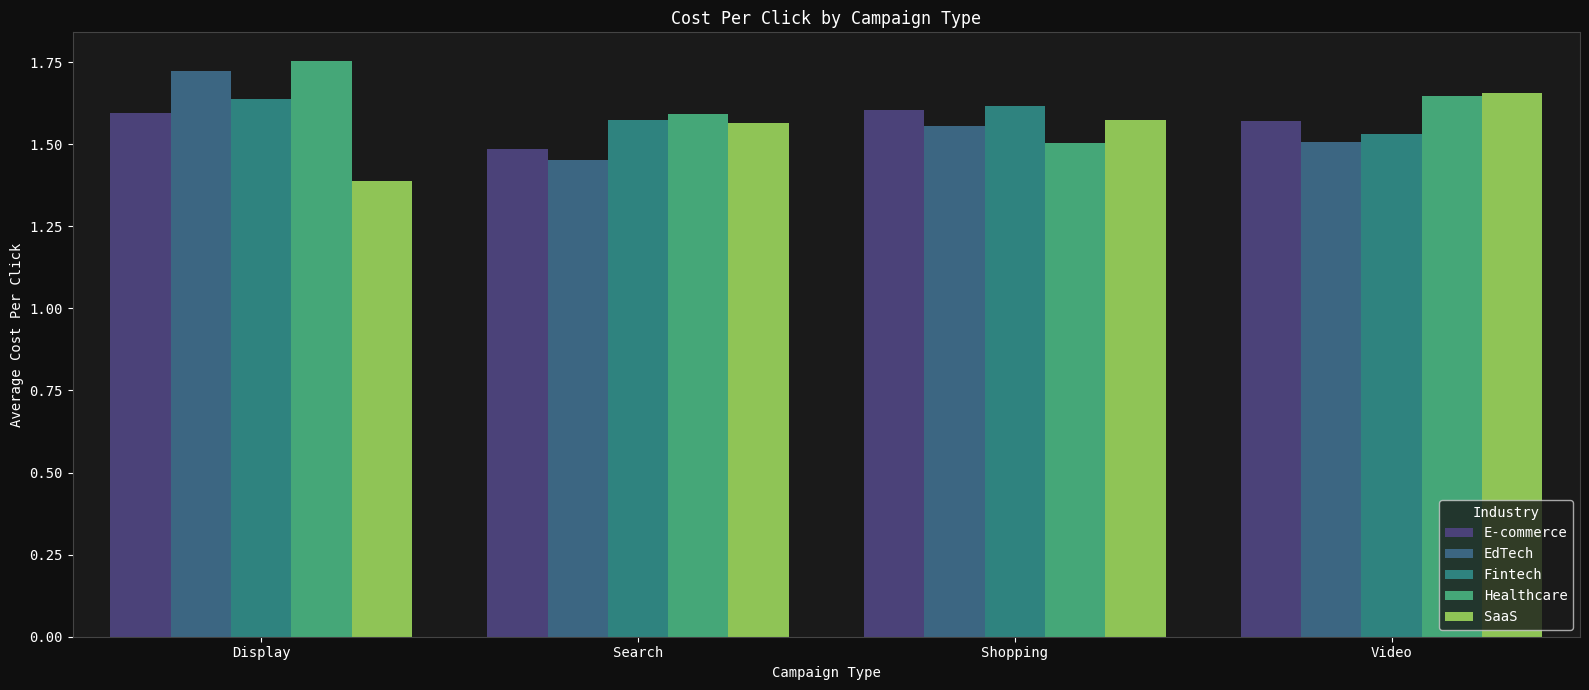

In [68]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data = cpc_efficiency, x='campaign_type', y='avg_cpc', hue='industry', palette = 'viridis')
plt.xlabel('Campaign Type')
plt.ylabel('Average Cost Per Click')
plt.title('Cost Per Click by Campaign Type')

legend = plt.gca().get_legend()
legend.set_title('Industry')
sns.move_legend(ax, 'lower right')

plt.tight_layout()
plt.show()

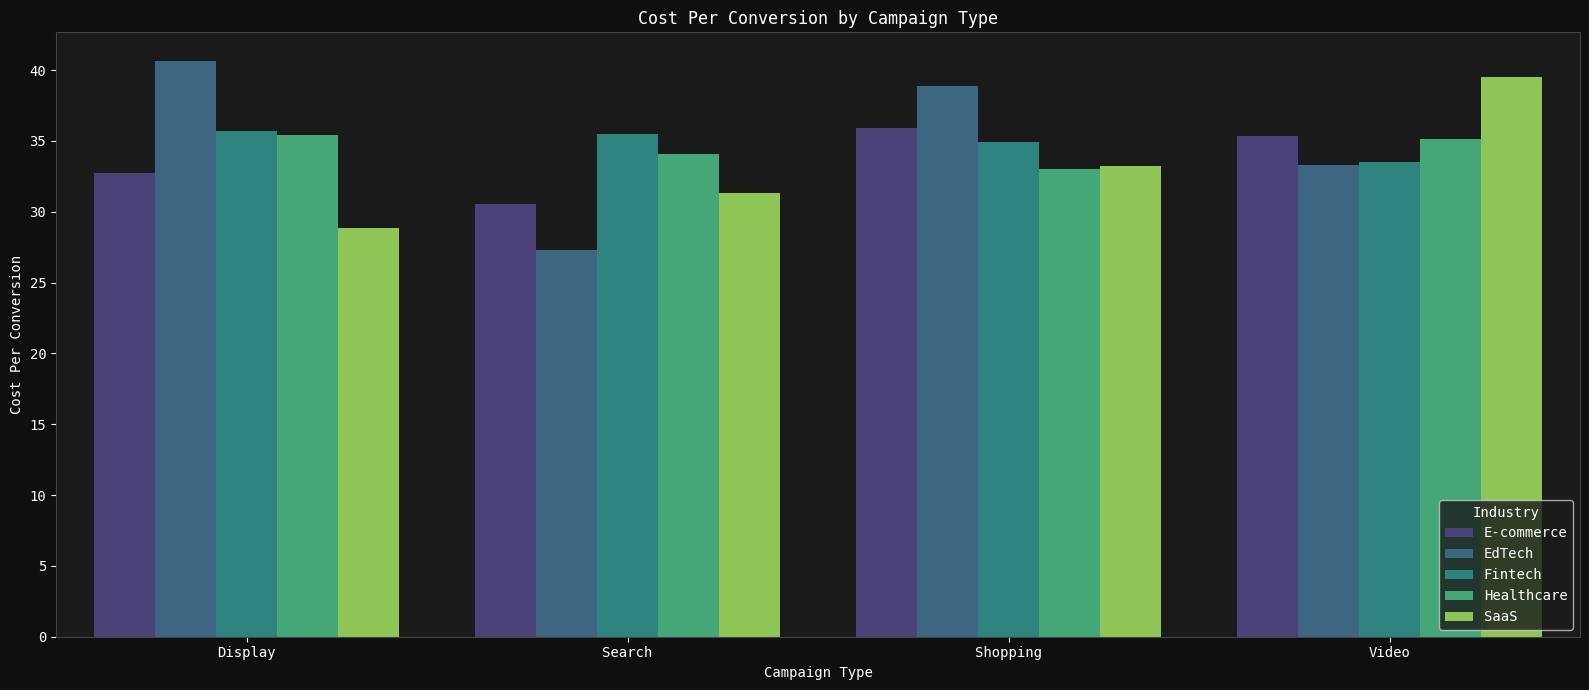

In [67]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data = cpc_efficiency, x='campaign_type', y='cost_per_conversion', hue='industry', palette = 'viridis')
plt.xlabel('Campaign Type')
plt.ylabel('Cost Per Conversion')
plt.title('Cost Per Conversion by Campaign Type')

legend = plt.gca().get_legend()
legend.set_title('Industry')
sns.move_legend(ax, 'lower right')

plt.tight_layout()
plt.show()

### Chart 5: Impression Volume v. Click Through Rate

In [81]:
impressions_vs_ctr_query = """
    SELECT campaign_type ||', '|| industry AS campaign_industry, SUM(impressions) AS total_impressions, SUM(clicks) AS total_clicks, AVG(CTR) AS avg_ctr
    FROM global_ads
    GROUP BY campaign_type, industry
    ORDER BY campaign_type, industry
"""

impressions_vs_ctr = pd.read_sql_query(impressions_vs_ctr_query, conn)
impressions_vs_ctr

,campaign_industry,total_impressions,total_clicks,avg_ctr
0,"Display, E-commerce",6573598,246905,0.038599
1,"Display, EdTech",9479765,324349,0.034981
2,"Display, Fintech",7903760,299524,0.038810
3,"Display, Healthcare",9563871,378613,0.039414
4,"Display, SaaS",9966110,389005,0.038834
5,"Search, E-commerce",9625424,380016,0.036802
6,"Search, EdTech",10757680,404634,0.037601
7,"Search, Fintech",9789164,380719,0.041603
8,"Search, Healthcare",9419699,381094,0.039511
9,"Search, SaaS",7952508,351764,0.042509


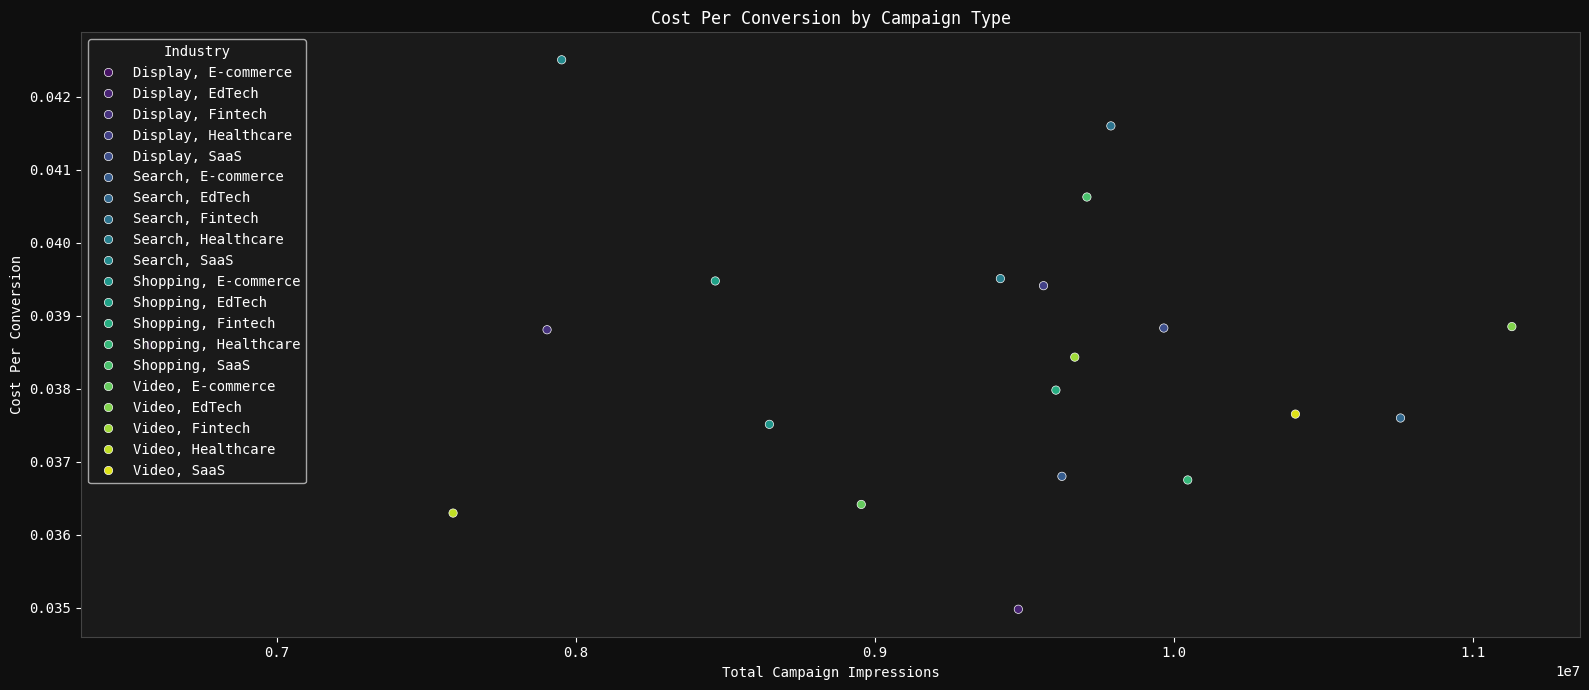

In [101]:
fig, ax = plt.subplots(figsize=(16,7))

sns.scatterplot(data = impressions_vs_ctr, x='total_impressions', y='avg_ctr', hue='campaign_industry', palette = 'viridis')
plt.xlabel('Total Campaign Impressions')
plt.ylabel('Cost Per Conversion')
plt.title('Cost Per Conversion by Campaign Type')

legend = plt.gca().get_legend()
legend.set_title('Industry')
sns.move_legend(ax, 'upper left')

plt.tight_layout()
plt.show()

## Platform $\times$ Industry Analysis
- Which platform performs best for each industry?
- Are some industries systematically over/under-spending relative to the revenue they generate?

### Charts __ & __: Platform Performance by Industry

## Geographic Insights
- Which countries generate the highest ROAS and why might they differ?
- Are there countries where a particular platform dominates in performance?

## Temporal Trends
- Are there seasonal patterns in ad spend, CTR, or ROAS across the year?
- Do conversion rates improve over time (possible learning/optimization effect)?

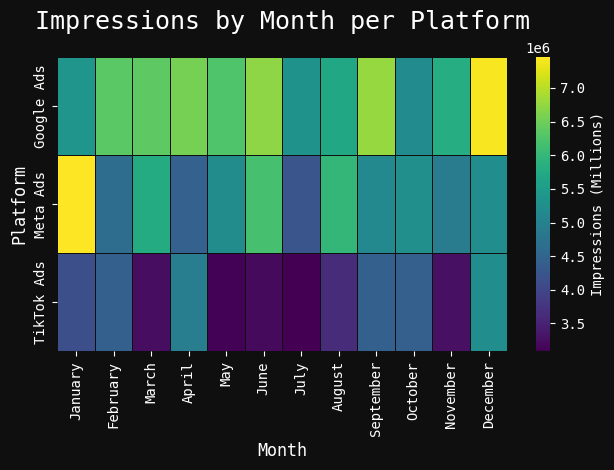

In [8]:
custom_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

heatmap1_pivot = query2_df.pivot_table(
    index = 'platform',
    columns = 'month',
    values = 'month_impressions'
)


sns.heatmap(heatmap1_pivot.reindex(columns=custom_order), 
            cmap = 'viridis', 
            linewidth = 0.5, 
            linecolor = '#0f0f0f', 
            annot = False, 
            cbar_kws = {'label': 'Impressions (Millions)'})

plt.title('Impressions by Month per Platform', fontsize = 18, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

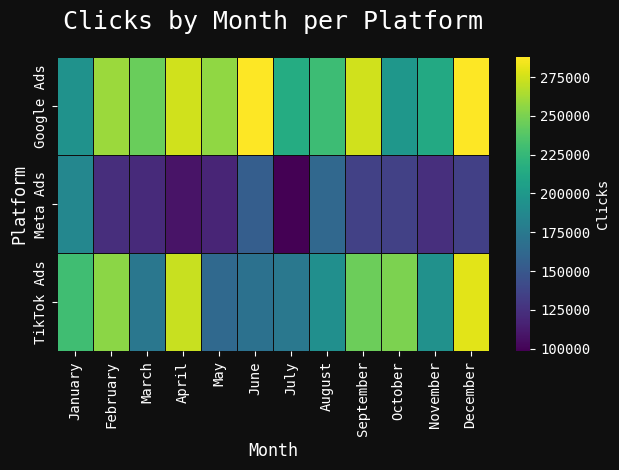

In [9]:
heatmap2_pivot = query2_df.pivot_table(
    index = 'platform',
    columns = 'month',
    values = 'month_clicks'
)


sns.heatmap(heatmap2_pivot.reindex(columns=custom_order), 
            cmap = 'viridis', 
            linewidth = 0.5, 
            linecolor = '#0f0f0f', 
            annot = False, 
            cbar_kws = {'label': 'Clicks'})

plt.title('Clicks by Month per Platform', fontsize = 18, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

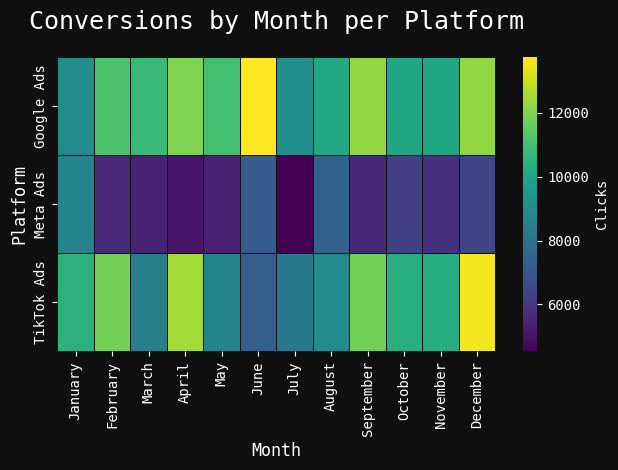

In [10]:
heatmap3_pivot = query2_df.pivot_table(
    index = 'platform',
    columns = 'month',
    values = 'month_conversions'
)


sns.heatmap(heatmap3_pivot.reindex(columns=custom_order), 
            cmap = 'viridis', 
            linewidth = 0.5, 
            linecolor = '#0f0f0f', 
            annot = False, 
            cbar_kws = {'label': 'Clicks'})

plt.title('Conversions by Month per Platform', fontsize = 18, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

## Anomaly & Outlier Detection
- Which campaigns have unusually high CPA and should be flagged for review?
- Are there cases where high spend leads to low ROAS -- and what do they have in common?

## Budget Optimization
- What is the optimal spend range where ROAS peaks before diminishing returns set in?
- If you had to cut 20% of spend, which platform/campaign-type combos should go first?